In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
import seaborn as sns

Text(0.5, 1.0, 'Before handling Outliers')

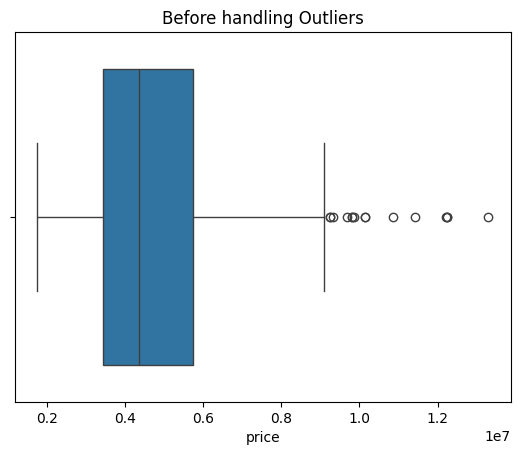

In [7]:
sns.boxplot(x=data['price'])
plt.title("Before handling Outliers")

Text(0.5, 1.0, 'Before handling Outliers')

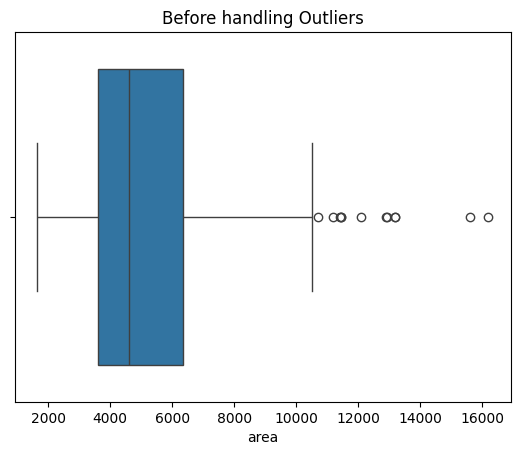

In [8]:
sns.boxplot(x=data['area'])
plt.title("Before handling Outliers")

In [9]:
import numpy as np
from scipy.stats import zscore

# Calculate z-scores
z_scores = zscore(data['price'])

# Identify outliers (|z| > 2)
data = data[np.abs(z_scores) <= 2]
data.shape

(519, 13)

Text(0.5, 1.0, 'After handling Outliers')

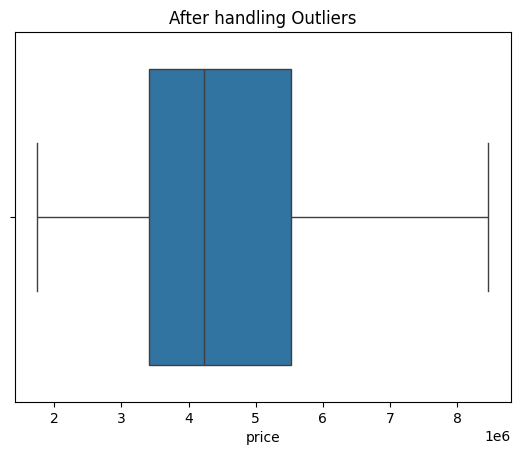

In [10]:
sns.boxplot(x=data['price'])
plt.title("After handling Outliers")


In [11]:


# Calculate z-scores
z_scores = zscore(data['area'])

# Identify outliers (|z| > 2)
data = data[np.abs(z_scores) <= 2]
data.shape

(498, 13)

Text(0.5, 1.0, 'After handling Outliers')

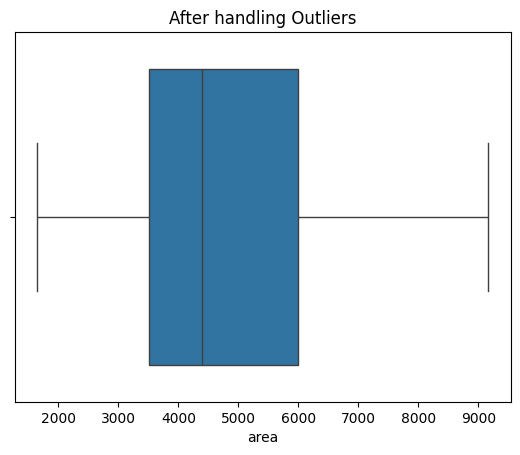

In [12]:
sns.boxplot(x=data['area'])
plt.title("After handling Outliers")

In [13]:
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_columns:
    data[col] = data[col].map({'yes': 1, 'no': 0})

In [14]:
data['furnishingstatus'].unique()

array(['semi-furnished', 'unfurnished', 'furnished'], dtype=object)

In [15]:
from sklearn.preprocessing import OrdinalEncoder

categories = [['unfurnished', 'semi-furnished', 'furnished']]

# Create the encoder
encoder = OrdinalEncoder(categories=categories)

# Apply encoding
data['furnishingstatus'] = encoder.fit_transform(data[['furnishingstatus']])
data


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
26,8463000,6000,3,2,4,1,1,1,0,1,0,1,1.0
27,8400000,8875,3,1,1,1,0,0,0,0,1,0,1.0
28,8400000,7950,5,2,2,1,0,1,1,0,2,0,0.0
29,8400000,5500,4,2,2,1,0,1,0,1,1,1,1.0
30,8400000,7475,3,2,4,1,0,0,0,1,2,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1.0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2.0


In [16]:
y = data['price']
x = data.drop('price',axis=1)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_test

534    2100000
104    6195000
275    4319000
216    4830000
282    4270000
        ...   
292    4200000
430    3290000
45     7560000
366    3675000
376    3640000
Name: price, Length: 100, dtype: int64

In [22]:
y_pred = model.predict(X_test)
y_pred


array([3440078.1312037 , 5809103.7202061 , 3581537.62868341,
       4562608.85563964, 3831716.57596354, 3522289.20017218,
       5985830.34204877, 5500862.45092165, 3548804.02288621,
       7368911.32867412, 5166154.59617095, 4119531.91823819,
       3203901.51708412, 5232189.51695879, 6481883.14508257,
       2887453.32293816, 2785004.72372799, 8565311.03469163,
       4641920.04415128, 2963275.40809856, 4087842.50530851,
       3958786.7901281 , 2439491.17371884, 6651709.11526678,
       6247581.74563399, 4940155.60132654, 3498890.72154364,
       2436064.90703235, 4305602.73709284, 5672541.99478274,
       4503058.84974585, 5435723.20250206, 5321330.03089158,
       6799062.32174155, 4321487.62944095, 5194959.88895757,
       4159093.15008324, 5587223.71084968, 2306953.57920178,
       4745579.88301328, 4987668.77947552, 2888060.35219074,
       5387910.45777952, 3791668.39412795, 7610590.84593238,
       8003231.99232116, 5609145.29170936, 3329054.4511619 ,
       5547412.32144262,

In [23]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6793054693290437

In [24]:
import  pickle

In [25]:
with open("model.pkl",'wb') as f:
    pickle.dump(model,f)